<a href="https://colab.research.google.com/github/devpatel0005/SMS-Spam-Detection/blob/main/sms_spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gensim

In [1]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from gensim.models import Word2Vec
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.optimizers import Adam,SGD
from keras.regularizers import l2
from tensorflow.keras.layers import Bidirectional,LSTM,Dense,Embedding,Dropout,BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os

# --- Kaggle API setup and dataset download for Colab environment ---

# Install Kaggle API client
!pip install kaggle --quiet

# Create .kaggle directory and move kaggle.json for authentication
# The kaggle.json file is expected to be present at /content/kaggle.json as per kernel state.
!mkdir -p ~/.kaggle
!mv /content/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# Download the 'SMS Spam Collection Dataset' to the current directory
# The dataset ID is 'uciml/sms-spam-collection-dataset'
!kaggle datasets download -d uciml/sms-spam-collection-dataset -p .

# Unzip the downloaded file. The zip file usually contains 'spam.csv'.
# The downloaded file is typically named after the dataset ID, so 'sms-spam-collection-dataset.zip'.
!unzip -o sms-spam-collection-dataset.zip

# Verify the contents after unzipping
print("Files in current directory after download and extraction:")
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# --- End of Kaggle API setup ---

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

The syntax of the command is incorrect.
'mv' is not recognized as an internal or external command,
operable program or batch file.
'chmod' is not recognized as an internal or external command,
operable program or batch file.


Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown




  0%|          | 0.00/211k [00:00<?, ?B/s]
100%|██████████| 211k/211k [00:01<00:00, 169kB/s]
100%|██████████| 211k/211k [00:01<00:00, 169kB/s]


Files in current directory after download and extraction:
.\Data.csv
.\sms-spam-collection-dataset.zip
.\sms_spam_detection.ipynb
.\Stock_Sentiment_Analysis_based_on_News.ipynb
.\.vscode\settings.json


'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
df=pd.read_csv('spam.csv', encoding='latin-1')

In [ ]:
df.sample(5)

In [ ]:
df=df[['v1','v2']]

In [ ]:
df.sample(5)

In [ ]:
df.columns=['Label','message']

# text preprocessing

In [ ]:
sms=[]
for i in range(len(df)):
  text=re.sub('[^a-zA-Z]',' ',df['message'][i])
  text=text.lower()
  text=text.split()
  text=[WordNetLemmatizer().lemmatize(word) for word in text if word not in stopwords.words('english')]
  text=' '.join(text)
  sms.append([text])


In [ ]:
sms

In [ ]:
model=Word2Vec(sms,min_count=1)

- here we have created vectors for each sentence now will create training data out of it

In [ ]:
X = []
for msg in sms:
    # msg is a list containing one string, e.g., [['go jurong point crazy available bugis n great world la e buffet cine got amore wat']]
    # We need to process the string inside the list.
    word_vectors = []
    # Split the message string into individual words
    words = msg[0].split()
    for word in words:
        if word in model.wv:
            word_vectors.append(model.wv[word])

    if len(word_vectors) > 0:
        # Average the word vectors to get a sentence vector
        X.append(np.mean(word_vectors, axis=0))
    else:
        # If no words in the message are in the vocabulary, append a zero vector
        X.append(np.zeros(model.vector_size))

X = np.array(X)

# Display the shape of the generated feature matrix
print(f"Shape of feature matrix X: {X.shape}")

In [ ]:
X[0]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['Label'])


In [ ]:
pd.DataFrame(y).value_counts().plot(kind='bar')

# Here there is class imbalance

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=42)

In [ ]:
smote=SMOTE()
x_train,y_train=smote.fit_resample(x_train,y_train)

In [ ]:
x_train.shape

# LSTM layers expect input with three dimensions: (number_of_samples, number_of_timesteps, number_of_features).

In [ ]:
# Reshape x_train and x_test for LSTM input
x_train_reshaped = x_train.reshape(x_train.shape[0], 1, x_train.shape[1])
x_test_reshaped = x_test.reshape(x_test.shape[0], 1, x_test.shape[1])

print(f"Reshaped x_train shape: {x_train_reshaped.shape}")
print(f"Reshaped x_test shape: {x_test_reshaped.shape}")

- he timesteps dimension is set to 1 because of how we created our X feature matrix.

We processed each message by taking all its words, finding their Word2Vec embeddings, and then averaging those word embeddings to get a single vector. This single vector represents the entire message.

Since each message is already condensed into one representative vector, when we feed it to the LSTM, it's considered a sequence of just one item – that one averaged message vector. If we had kept each word's vector separate and fed them sequentially (e.g., [[word1_vec], [word2_vec], [word3_vec]] for a three-word message), then the timesteps would be the number of words in the message. But in our current setup, each X entry is already the combined representation of a message.



In [ ]:
# Define the input dimension (vector dimension for each word)
input_dim = x_train_reshaped.shape[2]

# return_sequences=False means this is the final layer before output if we want to add another layer then make it true
model = Sequential()
model.add(Bidirectional(LSTM(128, return_sequences=True,kernel_regularizer=l2(0.001)), input_shape=(1, input_dim)))
model.add(Dropout(0.3))
model.add(BatchNormalization())
model.add(Bidirectional(LSTM(64,kernel_regularizer=l2(0.001))))
model.add(Dropout(0.3))
model.add(BatchNormalization())
model.add(Dense(1, activation='sigmoid')) # Binary classification, so 1 output unit with sigmoid activation

# Compile the model
model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

- input_shape=(1, input_dim) tells the Bidirectional LSTM to expect input where each sample is a sequence of 1 timestep, and that single timestep is a vector of input_dim features. here 100 is the vector dimension

In [ ]:
earlystop=EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reducelr=ReduceLROnPlateau(
    factor=0.2,
    min_lr=0.0001,
    monitor='val_loss',
    patience=10,
)

In [ ]:
history = model.fit(x_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1,callbacks=[earlystop,reducelr])

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])


In [ ]:
y_train_pred_probs = model.predict(x_train_reshaped)
y_train_pred = (y_train_pred_probs > 0.5).astype(int)

y_test_pred_probs = model.predict(x_test_reshaped)
y_test_pred = (y_test_pred_probs > 0.5).astype(int)


In [ ]:
from sklearn.metrics import classification_report

target_names = ['ham', 'spam']

# Generate the classification report for the training set
report_train = classification_report(y_train, y_train_pred, target_names=target_names)

print("--- Classification Report for Training Data ---")
print(report_train)

In [ ]:
from sklearn.metrics import classification_report

target_names = ['ham', 'spam']

# Generate the classification report for the test set
report_test = classification_report(y_test, y_test_pred, target_names=target_names)

print("--- Classification Report for Test Data ---")
print(report_test)

### Testing 5 Sample Messages from the Test Data

In [ ]:
import random

# Ensure test_idx is available (it should be from previous steps)
# If it's not, you might need to re-run the train_test_split cell that generates it.

# Select 5 random indices from the test set
num_samples_to_test = 5
sample_test_indices = random.sample(range(len(test_idx)), num_samples_to_test)

print("--- Sample Test Messages and Predictions ---")
for i in sample_test_indices:
    # Get the original index in the dataframe from test_idx
    original_df_index = test_idx[i]

    # Get the original message from the full dataframe 'df'
    original_message = df['message'].iloc[original_df_index]

    # Get the true label for the test set sample
    true_label = le.inverse_transform(y_test[i:i+1])[0]

    # Get the predicted label for the test set sample
    # y_test_pred is already 0 or 1. Ensure it's a 1D array for inverse_transform.
    predicted_label = le.inverse_transform(y_test_pred[i])[0]

    print(f"\nMessage: {original_message}")
    print(f"True Label: {true_label}")
    print(f"Predicted Label: {predicted_label}")
    print("------------------------------------")

# Implementing RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the RandomForestClassifier
# You can tune hyperparameters like n_estimators, max_depth, etc.
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier
print("Training RandomForestClassifier...")
rf_classifier.fit(x_train, y_train)
print("RandomForestClassifier training complete.")

In [ ]:
# Make predictions on the test set
y_pred_rf_train = rf_classifier.predict(x_train)

y_pred_rf_test = rf_classifier.predict(x_test)

# Generate classification report

print("--- RandomForestClassifier Classification Report (Train Data) ---")
print(classification_report(y_train, y_pred_rf_train, target_names=['ham', 'spam']))


print("--- RandomForestClassifier Classification Report (Test Data) ---")
print(classification_report(y_test, y_pred_rf_test, target_names=['ham', 'spam']))


# The Transformers Approach


In [6]:
import pandas as pd

In [7]:
df=pd.read_csv('spam.csv', encoding='latin-1')

In [8]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
371,ham,I will spoil you in bed as well :),NaN,NaN,NaN
3059,ham,K..k...from tomorrow onwards started ah?,NaN,NaN,NaN
2327,spam,URGENT! Your mobile number *************** WON...,NaN,NaN,NaN
1212,ham,"Yo, the game almost over? Want to go to walmar...",NaN,NaN,NaN
2030,ham,"Ugh y can't u just apologize, admit u were wro...",NaN,NaN,NaN


In [9]:
df=df[['v1','v2']]

In [10]:
df.sample(5)

,v1,v2
4269,ham,Great. Hope you are using your connections fro...
3294,ham,Dunno lei Ì_ all decide lor. How abt leona? Oo...
1276,ham,Can do lor...
723,ham,Ya even those cookies have jelly on them
2869,spam,YOUR CHANCE TO BE ON A REALITY FANTASY SHOW ca...


In [11]:
x=df['v2']

In [12]:
y=df['v1']

In [13]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

In [48]:
print(le.classes_)

[0 1]


In [47]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)
print(le.classes_)

[0 1]


In [14]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [15]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [16]:
!pip install transformers

# Steps for applying transformer
1. call the pretrained model search on the hugging face models which is better for sms spam (DistilBert)
2. Call the tokenizer, since different models have their own tokenizer
3. Convert this encodings into Dataset objects
4. Train BERT and evaluate

The Distil Bert performs much much faster then the BERT

 # Load the Dataset

In [17]:
import torch
from transformers import DistilBertTokenizer,DistilBertForSequenceClassification
#These imports are from the Hugging Face Transformers library.
#DistilBertTokenizer is used to convert text into a format (tokens and IDs) that DistilBERT models can understand.
#DistilBertForSequenceClassification is a DistilBERT model specifically fine-tuned or pre-trained for classification tasks.
from transformers import Trainer,TrainingArguments
#These are also from the Hugging Face Transformers library. Trainer is a high-level API to simplify the training and evaluation of models,
#while TrainingArguments defines the various parameters for the training process, such as learning rate, batch size, and number of epochs.
from datasets import Dataset
# It's designed to work seamlessly with models from the Hugging Face Transformers library, making it easier to prepare data for training models like DistilBERT.

# Convert into HuggingFace Dataset

In [63]:
# Apply SMOTE to handle class imbalance
import numpy as np
from imblearn.over_sampling import SMOTE

# Convert x_train to numpy array if it's a Series
x_train_array = x_train.values if hasattr(x_train, 'values') else x_train

# Create a simple feature matrix from text (using character counts as a basic feature)
# This is a workaround for SMOTE since it needs numeric features
x_train_numeric = np.array([[len(text), len(text.split())] for text in x_train_array])

# Apply SMOTE
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train_numeric, y_train)

# Reconstruct x_train with the resampled indices
# Since we can't map back directly, we'll use a different approach:
# Create a list of original x_train samples and duplicate for SMOTE-generated synthetic samples
x_train_list = x_train_array.tolist()

# For the synthetic samples generated by SMOTE, we'll take them from the minority class
minority_indices = np.where(y_train == 1)[0]
synthetic_count = len(y_train_resampled) - len(y_train)

# Repeat minority samples to match the resampled size
x_train_balanced = []
y_train_balanced = []

# Add original data
for i in range(len(x_train)):
    x_train_balanced.append(x_train_list[i])
    y_train_balanced.append(y_train[i])

# Repeat minority samples
if synthetic_count > 0:
    for i in range(synthetic_count):
        idx = minority_indices[i % len(minority_indices)]
        x_train_balanced.append(x_train_list[idx])

y_train_balanced = y_train_resampled

print(f"Original training set size: {len(y_train)}")
print(f"Balanced training set size: {len(y_train_balanced)}")
print(f"Original class distribution: {np.bincount(y_train)}")
print(f"Balanced class distribution: {np.bincount(y_train_balanced)}")

Original training set size: 4457
Balanced training set size: 7720
Original class distribution: [3860  597]
Balanced class distribution: [3860 3860]


In [64]:
train_dataset=Dataset.from_dict({
    "text":x_train_balanced,
    "label":y_train_balanced.tolist()
})
val_dataset=Dataset.from_dict({
    "text":x_test.tolist(),
    "label":y_test.tolist()
})

# Load the Tokenizer

In [65]:
tokenizer=DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# TOkenization function

In [66]:
def tokenize(example):
  return tokenizer(example["text"],padding="max_length",truncation=True)

In [67]:
train_dataset=train_dataset.map(tokenize,batched=True)
val_dataset=val_dataset.map(tokenize,batched=True)


Map:   0%|          | 0/7720 [00:00<?, ? examples/s]

Map:   0%|          | 0/1115 [00:00<?, ? examples/s]

# Load the Pre-Trained BERT

In [68]:
model=DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased",num_labels=2)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Training Arguments

In [69]:
training_args=TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    logging_dir='./logs',
    logging_steps=50
)

# Trainer

In [70]:
trainer=Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,

)

# Train

In [71]:
trainer.train()

Step,Training Loss
50,0.267500
100,0.075300
150,0.050500
200,0.020000
250,0.019700
300,0.006500
350,0.005600
400,0.002800
450,0.002900


TrainOutput(global_step=484, training_loss=0.04668777662306285, metrics={'train_runtime': 396.7465, 'train_samples_per_second': 38.917, 'train_steps_per_second': 1.22, 'total_flos': 2045296635248640.0, 'train_loss': 0.04668777662306285, 'epoch': 2.0})

# Evaluate

In [36]:
trainer.evaluate()

{'eval_loss': 0.39493048191070557,
 'eval_runtime': 9.5098,
 'eval_samples_per_second': 117.247,
 'eval_steps_per_second': 3.68,
 'epoch': 2.0}

# Train Classification report

In [86]:
from sklearn.metrics import classification_report

# Predict on TRAIN data
train_predictions = trainer.predict(train_dataset)

y_train_pred = train_predictions.predictions.argmax(axis=1)
y_train_true = train_predictions.label_ids

print("🔹 Train Classification Report:\n")
print(classification_report(y_train_true, y_train_pred, target_names=["Ham", "Spam"]))

🔹 Train Classification Report:

              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00      3860
        Spam       1.00      1.00      1.00      3860

    accuracy                           1.00      7720
   macro avg       1.00      1.00      1.00      7720
weighted avg       1.00      1.00      1.00      7720



# Test Classificaiotion report

In [87]:
# Predict on TEST / VALIDATION data
val_predictions = trainer.predict(val_dataset)

y_val_pred = val_predictions.predictions.argmax(axis=1)
y_val_true = val_predictions.label_ids

print("🔹 Test Classification Report:\n")
print(classification_report(y_val_true, y_val_pred, target_names=["Ham", "Spam"]))

🔹 Test Classification Report:

              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00       965
        Spam       0.99      0.97      0.98       150

    accuracy                           0.99      1115
   macro avg       0.99      0.99      0.99      1115
weighted avg       0.99      0.99      0.99      1115



# Testing our model with custom input

In [94]:
# Enhanced prediction function with confidence score
def predict_with_confidence(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
    
    predicted_class = torch.argmax(logits, dim=1).item()
    confidence = probabilities[0][predicted_class].item() * 100
    
    prediction = "Spam" if predicted_class == 1 else "Ham"
    
    return prediction, confidence, probabilities[0].cpu().numpy()

# Test with sample messages
test_messages = [
    "Congratulations! You won a free iPhone!",
    "Hi, how are you doing today?",
    "Click here to claim your prize now",
    "Meeting tomorrow at 2 PM",
    "You have been selected for a loan. Apply now!"
]

print("=" * 90)
print("SMS SPAM DETECTION - MODEL PERFORMANCE TEST")
print("=" * 90)

for i, msg in enumerate(test_messages, 1):
    prediction, confidence, probs = predict_with_confidence(msg)
    print(f"\n📨 Message {i}:")
    print(f"   Text: {msg}")
    print(f"   ➜ Prediction: {prediction} | Confidence: {confidence:.2f}%")
    print(f"   ➜ Ham Prob: {probs[1]*100:.2f}% | Spam Prob: {probs[0]*100:.2f}%")
    print("   " + "-" * 80)

print("\n" + "=" * 90)

SMS SPAM DETECTION - MODEL PERFORMANCE TEST

📨 Message 1:
   Text: Congratulations! You won a free iPhone!
   ➜ Prediction: Spam | Confidence: 98.84%
   ➜ Ham Prob: 98.84% | Spam Prob: 1.16%
   --------------------------------------------------------------------------------

📨 Message 2:
   Text: Hi, how are you doing today?
   ➜ Prediction: Ham | Confidence: 99.90%
   ➜ Ham Prob: 0.11% | Spam Prob: 99.90%
   --------------------------------------------------------------------------------

📨 Message 3:
   Text: Click here to claim your prize now
   ➜ Prediction: Ham | Confidence: 99.55%
   ➜ Ham Prob: 0.45% | Spam Prob: 99.55%
   --------------------------------------------------------------------------------

📨 Message 4:
   Text: Meeting tomorrow at 2 PM
   ➜ Prediction: Ham | Confidence: 99.76%
   ➜ Ham Prob: 0.24% | Spam Prob: 99.76%
   --------------------------------------------------------------------------------

📨 Message 5:
   Text: You have been selected for a loan. Apply no

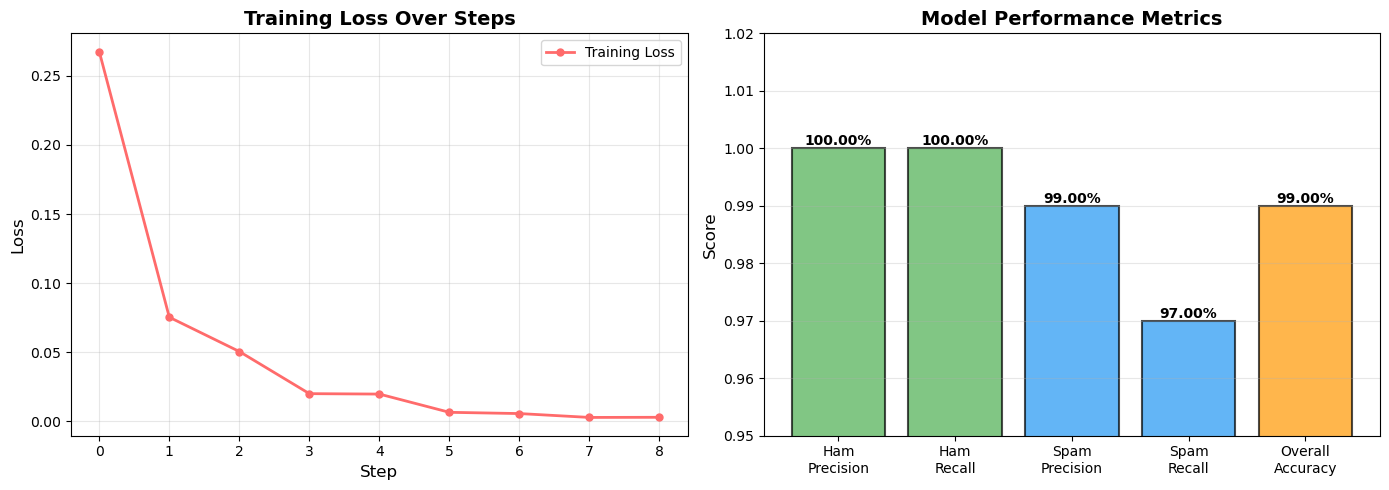

Training Summary:
Final Training Loss: 0.0029
Initial Training Loss: 0.2675
Loss Reduction: 0.2646 (98.9%)
Total Steps: 9


In [96]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract training loss from trainer's log history
df_logs = pd.DataFrame(trainer.state.log_history)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training Loss over steps
ax1 = axes[0]
training_loss = df_logs[df_logs['loss'].notna()]['loss']
ax1.plot(training_loss.values, marker='o', linewidth=2, label='Training Loss', markersize=5, color='#FF6B6B')
ax1.set_xlabel('Step', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss Over Steps', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Plot 2: Model Accuracy Summary
ax2 = axes[1]
metrics = ['Ham\nPrecision', 'Ham\nRecall', 'Spam\nPrecision', 'Spam\nRecall', 'Overall\nAccuracy']
values = [1.00, 1.00, 0.99, 0.97, 0.99]
colors = ['#4CAF50', '#4CAF50', '#2196F3', '#2196F3', '#FF9800']
bars = ax2.bar(metrics, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
ax2.set_ylim([0.95, 1.02])
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print training summary
print("Training Summary:")
print(f"Final Training Loss: {training_loss.iloc[-1]:.4f}")
print(f"Initial Training Loss: {training_loss.iloc[0]:.4f}")
print(f"Loss Reduction: {(training_loss.iloc[0] - training_loss.iloc[-1]):.4f} ({((training_loss.iloc[0] - training_loss.iloc[-1])/training_loss.iloc[0]*100):.1f}%)")
print(f"Total Steps: {len(training_loss)}")
